In [140]:
# !pip uninstall -y oceanttds

In [141]:
# !pip install "git+https://github.com/anthony-meza/oceanttds.git@inverse-gaussian"

In [142]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from oceanttds import * 
from tqdm.notebook import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [143]:
# --- 1. SETUP ---
# Grid MUST NOT contain 0 to avoid singularity in Inverse Gaussian PDF.
# We start at 0.1 years.
tau_grid = np.concatenate([
    [0.1],                     
    np.arange(3, 76, 3),       
    np.arange(80, 1001, 5),    
    [1200],                     
    np.arange(1500, 4001, 500), 
    [7000, 9000, 11000, 15000, 20000]  
]).astype(float)

In [190]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_boundary_sample_for_ttd.zarr"
ds_b = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__":"boundary_truth"}).fillna(0.0)
ds_b["boundary"] = ds_b["boundary_truth"].copy()

ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_interior_sample_for_ttd.zarr"
ds_i = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__": "interior_truth"}).fillna(0.0)
ds_i = ds_i.sel(time = slice(1975, 2030))
ds_i["interior"] = ds_i["interior_truth"].copy()


# noise_floors = xr.Dataset(
#     {"sigma_obs": (["tracer",], np.array([0.01, 0.01, 0.1]))}, 
#     coords={"tracer": ["cfc11", "cfc12", "sf6"]}
# )["sigma_obs"]

# ds_i["sigma_obs"] = xr.ufuncs.maximum( ds_i["interior_truth"] * 0.05, noise_floors)

ds_i["sigma_obs"] = (ds_i["interior_truth"] * 0.01).clip(min = 0.001)


In [205]:
gamma_bounds = (10, 5_000)
delta_gamma_ratio_bounds = (0.65, 2.5)
optimizer_options = {"maxiter": 200, "ftol": 1e-8, "early_stop": True, "early_stop_cost": 0.5}
warm_start_options = {"maxiter":1000}
warm_start = True 
debug = True

p0 = xr.Dataset(data_vars={
  "mass_fraction": (["source"], [0.5, 0.5]),
  "gamma": (["source"], [500, 500]),
  "delta_gamma_ratio": (["source"], [1.5, 1.5]),}, 
  coords={"source": ds_b.source})


results_control = solve_ttd_mixture(ds_b.sel(expt = "control"), ds_i.sel(expt = "control"), tau_grid=tau_grid, debug=debug, 
                            gamma_bounds = gamma_bounds, 
                           delta_gamma_ratio_bounds = delta_gamma_ratio_bounds, 
                                   optimizer_options = optimizer_options, 
                                   p0 = p0, 
                                   warm_start = warm_start, warm_start_options = warm_start_options)

p0 = xr.Dataset(data_vars={
  "mass_fraction": (["source"], [0.5, 0.5]),
  "gamma": (["source"], [500, 500]),
  "delta_gamma_ratio": (["source"], [1.5, 1.5]),}, 
  coords={"source": ds_b.source})


results_forced = solve_ttd_mixture(ds_b.sel(expt = "forced"), ds_i.sel(expt = "forced"), tau_grid=tau_grid, debug=debug, 
                            gamma_bounds = gamma_bounds, 
                           delta_gamma_ratio_bounds = delta_gamma_ratio_bounds, 
                                   optimizer_options = optimizer_options, 
                                   p0 = p0, 
                                   warm_start = warm_start, warm_start_options = warm_start_options)

results = xr.concat([results_control.expand_dims(expt=["control"]), results_forced.expand_dims(expt=["forced"])], dim = "expt")

print("Forced cost: ", results_forced.cost)
print("Control cost: ", results_control.cost)

Forced cost:  20.2110538482666
Control cost:  28.765153884887695


In [222]:
res = (ds_i.interior_truth - results.interior_fit) / ds_i["sigma_obs"] 
res = (res**2).sum(["tracer", "time"]) / (res*0 + 1).sum(["tracer", "time"]) 
res

<xarray.DataArray (expt: 2)> Size: 16B
array([28.76516008, 20.21105627])
Coordinates:
  * expt     (expt) object 16B 'control' 'forced'
    lat      float64 8B -50.0
    lon      float64 8B 120.0
    z_l      float64 8B 6.5e+03
Attributes:
    regrid_method:  bilinear
    units:          conc
    long_name:      Model Reconstruction

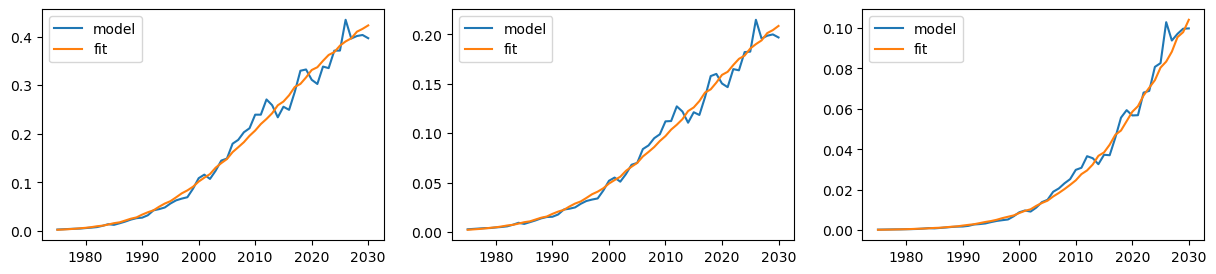

In [223]:
ntracers =len(ds_i.tracer)
expt = "control"
fig, ax = plt.subplots(1, ntracers, figsize = (15, 3))
for (itracer, tracer) in enumerate(ds_i.tracer):
    ax[itracer].plot(ds_i.time, ds_i.sel(expt = expt).interior_truth.sel(tracer = tracer), label = "model")
    ax[itracer].plot(ds_i.time, results.sel(expt = expt).interior_fit.sel(tracer = tracer), label = "fit")
    ax[itracer].legend()

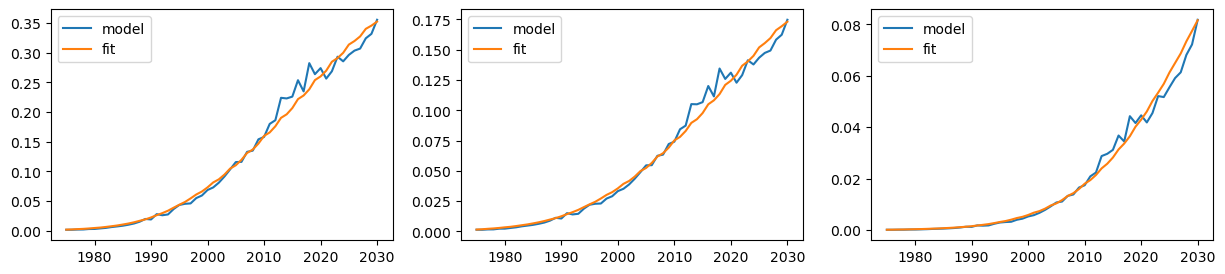

In [224]:
ntracers =len(ds_i.tracer)
expt = "forced"
fig, ax = plt.subplots(1, ntracers, figsize = (15, 3))
for (itracer, tracer) in enumerate(ds_i.tracer):
    ax[itracer].plot(ds_i.time, ds_i.sel(expt = expt).interior_truth.sel(tracer = tracer), label = "model")
    ax[itracer].plot(ds_i.time, results.sel(expt = expt).interior_fit.sel(tracer = tracer), label = "fit")
    ax[itracer].legend()
    

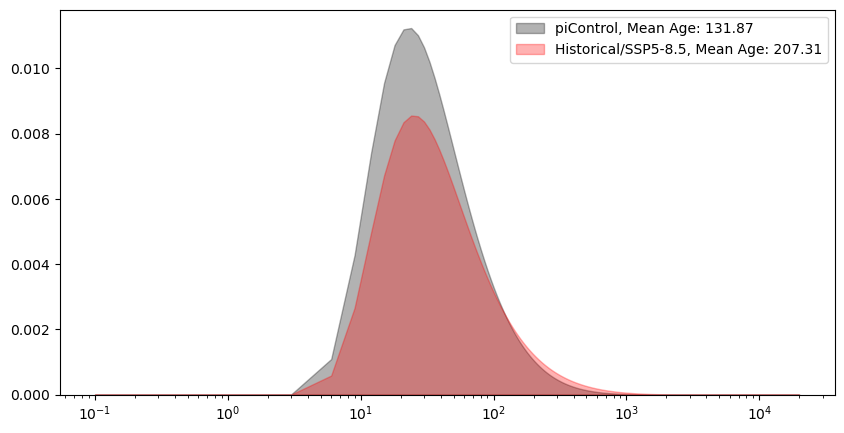

In [225]:
integrator = TTDIntegrator(tau_grid)
tau_dtau = integrator.weights * results.tau
mean_age = (results.age_spectrum* tau_dtau).sum(dim = "tau")

expt_labels = {"control":"piControl", "forced":"Historical/SSP5-8.5"}
expt_colors = {"control":"k", "forced":"r"}
fig, ax = plt.subplots(figsize = (10, 5))
for expt in results.expt.values:
    mean_age_expt = np.round(mean_age.sel(expt = expt).values, decimals = 2)
    ax.fill_between(results.tau, 0.0 * results.age_spectrum.sel(expt = expt), results.age_spectrum.sel(expt = expt), 
            color = expt_colors[expt], alpha = 0.3,
            label = f"{expt_labels[expt]}, Mean Age: {mean_age_expt}")
    # ax.axvline(mean_age_expt, c = expt_colors[expt])

ax.set_ylim(0.0, None)
ax.set_xscale('log')
ax.legend()